### Colab Activity 18.2: Bag of Words and TF-IDF

**Expected Time = 60 minutes**


In this activity you will use the Scikit-Learn vectorization tools `CountVectorizer` and  `TfidfVectorizer`  to create a bag of words representation of text in a DataFrame.  You will explore how different parameter settings affect the performance of a `LogisticRegression` estimator on a binary classification problem.https://www.google.com/url?q=https%3A%2F%2Fwww.kaggle.com%2Fdatasets%2Fuciml%2Fsms-spam-collection-dataset%3Fselect%3Dspam.csv

Thi activity uses the [SMS Spam Collection](https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset?select=spam.csv) dataset. This dataset contains is a set of 5,574 SMS tagged messages according being ham (legitimate) or spam.

- [Problem 1](#-Problem-1)
- [Problem 2](#-Problem-2)
- [Problem 3](#-Problem-3)
- [Problem 4](#-Problem-4)
- [Problem 5](#-Problem-5)
- [Problem 6](#-Problem-6)
- [Problem 7](#-Problem-7)

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,  TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import  classification_report
import string

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
def head2(df):
  return df.head(2)

In [6]:
email_data = pd.read_csv('/content/sample_data/spam.csv', encoding = 'latin-1' )

In [ ]:
email_data.head(5)

## Exploratory data analysis

In [ ]:
sns.countplot(email_data['v1'], label = "Count of the Labels")

From the count plot, the dataset appears not to be balanced. There are more data that are classified as ham other than spam.

## Data Cleaning and Data Preprocessing


Before the data can be fed to a machine learning model, it is required to clean the data first.



In [7]:
#dropping the columnns with NaNs
email_data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], axis  = 1, inplace = True)

In [8]:
#renaming the remaining columns
email_data = email_data.rename(columns = {"v1": "label", "v2": "text"})

In [9]:
email_data.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


The function `clean_review` below removes all the punctuations and all the common words.

In [10]:
def clean_review(review):
    remove_punctuation = [word for word in review if word not in string.punctuation]
    join_characters = ''.join(remove_punctuation)
    remove_stopwords = [word for word in join_characters.split() if word not in stopwords.words('english')]
    cleaned_review = remove_stopwords
    return cleaned_review

In [69]:
## TEST FOR UNDERSTANDING THE FUNCTION
text ="pwd fr My! mail id is o, rt"
cleaned_review  = clean_review("pwd fr my! mail id is o, rt")

wopunc= [word for word in text if word not in string.punctuation]
wopunc= ''.join(wopunc)
remove_stopwords = [word for word in wopunc.split() if word.lower() not in stopwords.words('english')]

print(remove_stopwords)


['pwd', 'fr', 'mail', 'id', 'rt']


[Back to top](#-Index)

### Problem 1

#### Using the `CountVectorizer`


To create a bag of words representation of your text data, below create an instance of the `CountVectorizer` with argument `analyzer` equal to `clean_review`  as `count_vectorizer`.

Next, use the `fit_transform` function on `count_vectorizer` to transform the `text` column of the `email_data` DataFrame and assign the transformed version of the text to `email_countvec`.  


In [32]:
import timeit
count_vectorizer = CountVectorizer(analyzer=clean_review)
start = timeit.default_timer()
email_countvec = count_vectorizer.fit_transform(email_data['text'])
end = timeit.default_timer()
#calculate the time in seconds and print
print(end - start)

7.4850045260000115


In [33]:
head2(email_data['text'])

,text
0,"Go until jurong point, crazy.. Available only ..."
1,Ok lar... Joking wif u oni...


[Back to top](#-Index)

### Problem 2

#### Encoding the Dependent Variable `label`

In the code cell below, initialize an instance of `LabelEncoder` and assign it to the variable `le`.



Next, use the `fit_transform` function on `le` to transform the `label` column of the `email_data` DataFrame and assign the transformed version of the text to `email_data['label']`.  

In [34]:
le = LabelEncoder()# works by classifying unique labels in alphabetical order hence ham=0, spam=1
email_data['label'] = le.fit_transform(email_data["label"])
head2(email_data['label'])

,label
0,0
1,0


## Splitting the Data into Training and Testing

Run the code cells below to split the data into training and testing sets.


In [35]:
X = email_countvec
y = email_data['label']

In [36]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25)

[Back to top](#-Index)

### Problem 3

#### Classification using `LogisticRegression`

In the code cell below, instantiate an instance of the `LogisticRegression` classifier with default parameters and assign it to the variable `classifier`.

Fit this classifier on the training data `X_train` and `y_train`.


In [51]:
classifier = LogisticRegression()
classifier.fit(X_train,y_train)


LogisticRegression()

[Back to top](#-Index)

### Problem 4

#### Evaluating the CountVectorizer Model

In the code cell below, use the `predict` function on `classifier` to compute the predictions on the test set `X_test`. Assign the result to `y_pred`.

Next, use `classification_report` to print a report of your findings using `y_test` and `y_pred`.

In [76]:
y_pred=classifier.predict(X_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1224
           1       0.99      0.83      0.90       169

    accuracy                           0.98      1393
   macro avg       0.98      0.92      0.95      1393
weighted avg       0.98      0.98      0.98      1393



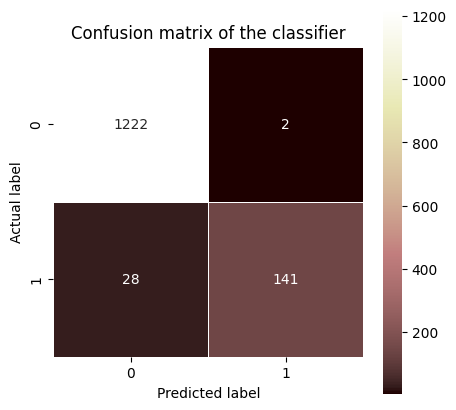

In [68]:
#Print the confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,5))
sns.heatmap(cm, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'pink')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
plt.title('Confusion matrix of the classifier')
plt.show()

In [58]:
#       precision    recall  f1-score   support

#            0       0.98      1.00      0.99      1222
#            1       1.00      0.84      0.91       171

#     accuracy                           0.98      1393
#    macro avg       0.99      0.92      0.95      1393
# weighted avg       0.98      0.98      0.98      1393

[Back to top](#-Index)

### Problem 5

#### Using TF-IDF

In the code cell below, create an instance of the `TfidfVectorizer` with default parameters as `tfidf`, with argument `analyzer` equal to `clean_review`.

Next, use the `fit_transform` function on `tfidf` to transform the `text` column of the `email_data` DataFrame and assign the transformed version of the text to `tfidfvec`.  

In [70]:
tfidf = TfidfVectorizer(analyzer=clean_review)
tfidvec = tfidf.fit_transform(email_data['text'])

## Splitting the Data into Training and Testing

Run the code cells below to split the data into training and testing sets.

In [71]:
X2 = tfidvec
y2 = email_data['label']

In [72]:
X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size = 0.25)

[Back to top](#-Index)

### Problem 6

#### Classification using `LogisticRegression`

In the code cell below, instantiate an instance of the `LogisticRegression` classifier with default parameters and assign it to the variable `classifier2`.

Fit this classifier on the training data `X_train2` and `y_train2`.

In [79]:
classifier2 = LogisticRegression()
classifier2.fit(X_train2,y_train2)
classifier2

LogisticRegression()

[Back to top](#-Index)

### Problem 7

#### Evaluating the TF-IDF Model

In the code cell below, use the `predict` function on `classifier2` to compute the predictions on the test set `X_test2`. Assign the result to `y_pred2`.

Next, use `classification_report` to print a report of your findings using `y_test2` and `y_pred2`.

              precision    recall  f1-score   support

           0       0.96      1.00      0.98      1228
           1       0.98      0.72      0.83       165

    accuracy                           0.97      1393
   macro avg       0.97      0.86      0.91      1393
weighted avg       0.97      0.97      0.96      1393



In [83]:
y_pred2 = classifier2.predict(X_test2)
print(classification_report(y_test2,y_pred2))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1211
           1       0.99      0.58      0.73       182

    accuracy                           0.94      1393
   macro avg       0.97      0.79      0.85      1393
weighted avg       0.95      0.94      0.94      1393



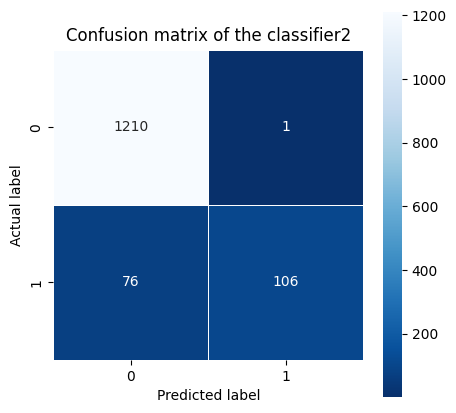

In [84]:
#Print the confusion matrix
cm2 = confusion_matrix(y_test2, y_pred2)
plt.figure(figsize=(5,5))
sns.heatmap(cm2, annot=True, fmt=".0f", linewidths=.5, square = True, cmap = 'Blues_r')
plt.ylabel('Actual label');
plt.xlabel('Predicted label');
plt.title('Confusion matrix of the classifier2')
plt.show()

Comment on the performance of the two models.

In [ ]:
# The recall and F1-score are higher for BOW model than TFIDF for this spam data set . Recall is far better in the former case.
# Key Spam Indicators: Spam messages frequently rely on a set of common 'spammy' words (e.g., 'free', 'win', 'money', 'urgent', 'guarantee').
# BOW's Strength: A simple count (as in BOW) directly captures the presence and high frequency of these words within a message. If a message contains multiple instances of such words, BOW assigns it a higher value for those terms, making it easier for the classifier to identify it as spam.
# TF-IDF's Limitation: TF-IDF, on the other hand, down-weights words that are common across many documents in the entire corpus, even if they are very frequent within a specific document. If those 'spammy' keywords also appear occasionally in legitimate (ham) messages, or if they are just common enough across the overall dataset (ham and spam combined), TF-IDF might reduce their importance. This can make the signal weaker for the classifier.
